第一步：读取数据与拟合静爆基准公式

In [3]:
%% 第一步：读取数据与拟合高精度静爆基准公式 (15参数傅里叶解耦版)
disp('>>> 开始步骤1：提取高精度静爆本底 (15参数傅里叶解耦模型)...');

% 1. 读取数据
opts = detectImportOptions('zhuxing1.xlsx');
opts.VariableNamingRule = 'preserve';
df = readtable('zhuxing1.xlsx', opts);
df.Properties.VariableNames(1:6) = {'M', 'H', 'V', 'P_MPa', 'Z', 'theta'};

% 2. 预处理环境因子 (萨克斯定律)
T0 = 288.15;
df.T_h = T0 - 6.5 * df.H;
df.Sp = (df.T_h / T0) .^ 5.25588;

% 3. 提取静爆数据
df_static = df(df.V == 0, :);

% 4. 定义全新 15参数 高阶静爆模型
% 采用 cos(k*theta) 完美捕捉 0度与180度不对称性，且远、中、近场独立解耦
static_model = @(p, X) ...
    (X(:,2).^(2/3) ./ X(:,1))   .* ( p(1) + p(2).*cosd(X(:,3)) + p(3).*cosd(2*X(:,3)) + p(4).*cosd(3*X(:,3)) + p(5).*cosd(4*X(:,3)) ) ...
  + (X(:,2).^(1/3) ./ X(:,1).^2) .* ( p(6) + p(7).*cosd(X(:,3)) + p(8).*cosd(2*X(:,3)) + p(9).*cosd(3*X(:,3)) + p(10).*cosd(4*X(:,3)) ) ...
  + (1 ./ X(:,1).^3)             .* ( p(11) + p(12).*cosd(X(:,3)) + p(13).*cosd(2*X(:,3)) + p(14).*cosd(3*X(:,3)) + p(15).*cosd(4*X(:,3)) );

% 5. 初始化猜测值与求解器配置
X_stat = [df_static.Z, df_static.Sp, df_static.theta];
y_stat = df_static.P_MPa;

p0_stat = 0.01 * ones(1, 15);
p0_stat(1) = 0.065; p0_stat(6) = 0.397; p0_stat(11) = 0.322; % 锚定经典爆炸当量的经验主轴常数

options_stat = optimoptions('lsqcurvefit', 'Algorithm', 'trust-region-reflective', ...
    'Display', 'off', 'MaxFunctionEvaluations', 100000, 'MaxIterations', 5000);

% 6. 拟合求解
[p_stat, ~] = lsqcurvefit(static_model, p0_stat, X_stat, y_stat, [], [], options_stat);

% ==================== 【关键修改点】 ====================
% 强制将拟合出的系数全局保留 4 位小数，确保论文公式的计算误差与代码完全一致
p_stat = round(p_stat, 4);
% ========================================================

% 提取常数项供第二步动爆作为起始猜测值
A = p_stat(1); B = p_stat(6); C = p_stat(11);

% 7. 计算并输出精细误差指标 (此时使用的是截断后的 4 位小数系数)
y_stat_calc = static_model(p_stat, X_stat);
R2_stat = 1 - sum((y_stat - y_stat_calc).^2) / sum((y_stat - mean(y_stat)).^2);
abs_err_stat = abs(y_stat_calc - y_stat);
rel_err_stat = (abs_err_stat ./ y_stat) * 100;

MAE_stat = mean(abs_err_stat);
MAPE_stat = mean(rel_err_stat);

fprintf('\n✅ 第一步高精度静爆拟合完成！\n');
fprintf('🎉 拟合优度 R^2 = %.4f\n', R2_stat);
fprintf('📉 平均绝对误差 (MAE)  : %.5f MPa\n', MAE_stat);
fprintf('📉 平均相对误差 (MAPE) : %.2f %%\n\n', MAPE_stat);

fprintf('================ 升级版静爆公式全貌 =================\n');
fprintf('P_stat = (Sp^(2/3)/Z)   * [ (%.4f) + (%.4f)*cos(θ) + (%.4f)*cos(2θ) + (%.4f)*cos(3θ) + (%.4f)*cos(4θ) ]\n', p_stat(1:5));
fprintf('       + (Sp^(1/3)/Z^2) * [ (%.4f) + (%.4f)*cos(θ) + (%.4f)*cos(2θ) + (%.4f)*cos(3θ) + (%.4f)*cos(4θ) ]\n', p_stat(6:10));
fprintf('       + (1/Z^3)        * [ (%.4f) + (%.4f)*cos(θ) + (%.4f)*cos(2θ) + (%.4f)*cos(3θ) + (%.4f)*cos(4θ) ]\n', p_stat(11:15));
fprintf('=====================================================\n');

>>> 开始步骤1：提取高精度静爆本底 (15参数傅里叶解耦模型)...

✅ 第一步高精度静爆拟合完成！
🎉 拟合优度 R^2 = 0.9895
📉 平均绝对误差 (MAE)  : 0.01784 MPa
📉 平均相对误差 (MAPE) : 10.78 %

================ 升级版静爆公式全貌 =================
P_stat = (Sp^(2/3)/Z)   * [ (0.0323) + (0.0000)*cos(θ) + (0.1570)*cos(2θ) + (0.0000)*cos(3θ) + (-0.0871)*cos(4θ) ]
       + (Sp^(1/3)/Z^2) * [ (0.4871) + (-0.0000)*cos(θ) + (-0.6306)*cos(2θ) + (-0.0000)*cos(3θ) + (0.0824)*cos(4θ) ]
       + (1/Z^3)        * [ (0.1941) + (-0.0000)*cos(θ) + (0.0890)*cos(2θ) + (0.0000)*cos(3θ) + (0.2346)*cos(4θ) ]



静爆相关图

第二步：用 $k=4$ 的公式形式拟合动爆全域公式

In [5]:
%% 第二步：用 k=4 公式形式拟合绝对动爆公式 (优化版)
disp('>>> 开始步骤2：进行 33 参数高阶多项式-傅里叶耦合拟合...');

df_dyn = df(df.V > 0, :);
X_dyn = [df_dyn.Z, df_dyn.Sp, df_dyn.theta, df_dyn.V];
y_dyn = df_dyn.P_MPa;

% 核心模型定义 (V_n = V/1000 归一化)
dyn_model = @(c, X) ...
    (X(:,2).^(2/3) ./ X(:,1)) .* ( c(1) + c(2).*(X(:,4)/1000) + c(3).*(X(:,4)/1000).^2 + ...
        (c(4) + c(5).*(X(:,4)/1000)).*cosd(X(:,3)) + (c(6) + c(7).*(X(:,4)/1000)).*cosd(2*X(:,3)) + ...
        (c(8) + c(9).*(X(:,4)/1000)).*cosd(3*X(:,3)) + (c(10) + c(11).*(X(:,4)/1000)).*cosd(4*X(:,3)) ) ...
    + ...
    (X(:,2).^(1/3) ./ X(:,1).^2) .* ( c(12) + c(13).*(X(:,4)/1000) + c(14).*(X(:,4)/1000).^2 + ...
        (c(15) + c(16).*(X(:,4)/1000)).*cosd(X(:,3)) + (c(17) + c(18).*(X(:,4)/1000)).*cosd(2*X(:,3)) + ...
        (c(19) + c(20).*(X(:,4)/1000)).*cosd(3*X(:,3)) + (c(21) + c(22).*(X(:,4)/1000)).*cosd(4*X(:,3)) ) ...
    + ...
    (1 ./ X(:,1).^3) .* ( c(23) + c(24).*(X(:,4)/1000) + c(25).*(X(:,4)/1000).^2 + ...
        (c(26) + c(27).*(X(:,4)/1000)).*cosd(X(:,3)) + (c(28) + c(29).*(X(:,4)/1000)).*cosd(2*X(:,3)) + ...
        (c(30) + c(31).*(X(:,4)/1000)).*cosd(3*X(:,3)) + (c(32) + c(33).*(X(:,4)/1000)).*cosd(4*X(:,3)) );

c0 = 0.05 * ones(1, 33);
c0(1) = A; c0(12) = B; c0(23) = C; 

options_dyn = optimoptions('lsqcurvefit', 'Algorithm', 'trust-region-reflective', 'Display', 'off', 'MaxFunctionEvaluations', 2000000);
[c_opt, ~] = lsqcurvefit(dyn_model, c0, X_dyn, y_dyn, [], [], options_dyn);

% ==================== 【关键修改点】 ====================
% 强制将拟合出的系数全局保留 4 位小数，确保计算误差与论文公式完全一致
c_opt = round(c_opt, 4);
% ========================================================

% 获取预测值 (使用截断后的 4 位小数系数计算)
P_dyn_pred = dyn_model(c_opt, X_dyn);
df_dyn.P_pred = P_dyn_pred;
R2_dyn = 1 - sum((y_dyn - P_dyn_pred).^2) / sum((y_dyn - mean(y_dyn)).^2);

% ==================== 新增误差计算模块 ====================
abs_err_dyn = abs(y_dyn - P_dyn_pred);
rel_err_dyn = (abs_err_dyn ./ y_dyn) * 100;

MAE_dyn = mean(abs_err_dyn);
MAPE_dyn = mean(rel_err_dyn);
% ==========================================================

fprintf('\n✅ 动爆高阶模型拟合成功！ 最终 R^2 = %.4f\n', R2_dyn);
fprintf('📉 平均绝对误差 (MAE)  : %.5f MPa\n', MAE_dyn);
fprintf('📉 平均相对误差 (MAPE) : %.2f %%\n\n', MAPE_dyn);

fprintf('====================== 动爆公式全貌与 33 个核心系数 ======================\n');
fprintf('P_dyn = Term1 (远场 1/Z) + Term2 (中场 1/Z^2) + Term3 (近场 1/Z^3)\n');
fprintf('其中: V_n = V / 1000\n\n');

fprintf('【Term1】= (Sp^(2/3)/Z) * [ (%.4f) + (%.4f)*V_n + (%.4f)*V_n^2 \n', c_opt(1), c_opt(2), c_opt(3));
fprintf('            + (%.4f + %.4f*V_n)*cos(θ) + (%.4f + %.4f*V_n)*cos(2θ)\n', c_opt(4), c_opt(5), c_opt(6), c_opt(7));
fprintf('            + (%.4f + %.4f*V_n)*cos(3θ) + (%.4f + %.4f*V_n)*cos(4θ) ]\n\n', c_opt(8), c_opt(9), c_opt(10), c_opt(11));

fprintf('【Term2】= (Sp^(1/3)/Z^2)* [ (%.4f) + (%.4f)*V_n + (%.4f)*V_n^2 \n', c_opt(12), c_opt(13), c_opt(14));
fprintf('            + (%.4f + %.4f*V_n)*cos(θ) + (%.4f + %.4f*V_n)*cos(2θ)\n', c_opt(15), c_opt(16), c_opt(17), c_opt(18));
fprintf('            + (%.4f + %.4f*V_n)*cos(3θ) + (%.4f + %.4f*V_n)*cos(4θ) ]\n\n', c_opt(19), c_opt(20), c_opt(21), c_opt(22));

fprintf('【Term3】= (1/Z^3) * [ (%.4f) + (%.4f)*V_n + (%.4f)*V_n^2 \n', c_opt(23), c_opt(24), c_opt(25));
fprintf('            + (%.4f + %.4f*V_n)*cos(θ) + (%.4f + %.4f*V_n)*cos(2θ)\n', c_opt(26), c_opt(27), c_opt(28), c_opt(29));
fprintf('            + (%.4f + %.4f*V_n)*cos(3θ) + (%.4f + %.4f*V_n)*cos(4θ) ]\n', c_opt(30), c_opt(31), c_opt(32), c_opt(33));
fprintf('==========================================================================\n');

>>> 开始步骤2：进行 33 参数高阶多项式-傅里叶耦合拟合...

✅ 动爆高阶模型拟合成功！ 最终 R^2 = 0.9692
📉 平均绝对误差 (MAE)  : 0.02753 MPa
📉 平均相对误差 (MAPE) : 11.86 %

====================== 动爆公式全貌与 33 个核心系数 ======================
P_dyn = Term1 (远场 1/Z) + Term2 (中场 1/Z^2) + Term3 (近场 1/Z^3)
其中: V_n = V / 1000

【Term1】= (Sp^(2/3)/Z) * [ (0.0435) + (-0.0351)*V_n + (-0.0147)*V_n^2 
            + (-0.0031 + -0.1084*V_n)*cos(θ) + (0.1330 + 0.0295*V_n)*cos(2θ)
            + (-0.0274 + 0.2357*V_n)*cos(3θ) + (-0.1473 + 0.1875*V_n)*cos(4θ) ]

【Term2】= (Sp^(1/3)/Z^2)* [ (0.4825) + (0.0154)*V_n + (0.1787)*V_n^2 
            + (-0.0501 + 0.6864*V_n)*cos(θ) + (-0.6347 + 0.0929*V_n)*cos(2θ)
            + (0.0234 + -0.6430*V_n)*cos(3θ) + (0.2190 + -0.4528*V_n)*cos(4θ) ]

【Term3】= (1/Z^3) * [ (0.1899) + (-0.0000)*V_n + (-0.0003)*V_n^2 
            + (-0.0056 + 0.1281*V_n)*cos(θ) + (0.0592 + 0.0960*V_n)*cos(2θ)
            + (0.0188 + 0.1185*V_n)*cos(3θ) + (0.2341 + -0.0328*V_n)*cos(4θ) ]



第三步：计算平均误差指标并生成误差四宫格图

第四步：输出排序归类好的误差表格

In [7]:
%% 第四步：生成双版 Excel 输出表格 (工况排序版 vs 相对误差排序版)
disp('>>> 开始生成双版本 Excel 数据输出...');

% 1. 提取我们关心的核心列，并新增一列用于纯粹的误差绝对大小排序
cols_to_extract = {'M', 'H', 'V', 'Z', 'theta', 'P_MPa', 'P_pred', 'Abs_Error', 'Rel_Error_Pct'};
df_out = df_dyn(:, cols_to_extract);

% 为了方便排序，加一个相对误差绝对值列，算完后可以删掉它或者保留
df_out.Error_Magnitude = abs(df_out.Rel_Error_Pct);

% 修改为中文规范表头
df_out.Properties.VariableNames{'P_pred'} = 'P_拟合计算值_MPa';
df_out.Properties.VariableNames{'Abs_Error'} = '绝对误差_MPa';
df_out.Properties.VariableNames{'Rel_Error_Pct'} = '相对误差_百分比';
df_out.Properties.VariableNames{'Error_Magnitude'} = '误差绝对大小_用于排序';

% ==================== 版本 A：按物理工况多级排序 ====================
% 优先级：H -> V -> Z -> theta
df_by_condition = sortrows(df_out, {'H', 'V', 'Z', 'theta'});
% 导出表格 A
filename_A = '高阶k4_最终结果_按工况排序.xlsx';
writetable(df_by_condition, filename_A);
fprintf('✅ 表格 A 导出成功：【 %s 】(适合编入查阅手册)\n', filename_A);

% ==================== 版本 B：按相对误差大小排序 ====================
% 按照刚刚算好的 Error_Magnitude 列进行降序 (descend) 排列
df_by_error = sortrows(df_out, '误差绝对大小_用于排序', 'descend');
% 导出表格 B
filename_B = '高阶k4_最终结果_按误差大小排序.xlsx';
writetable(df_by_error, filename_B);
fprintf('✅ 表格 B 导出成功：【 %s 】(适合排查残差痛点)\n', filename_B);

disp('🎉 所有四大模块全部运行完毕，您的模型已具备极高的工程实战价值！');

>>> 开始生成双版本 Excel 数据输出...
✅ 表格 A 导出成功：【 高阶k4_最终结果_按工况排序.xlsx 】(适合编入查阅手册)
✅ 表格 B 导出成功：【 高阶k4_最终结果_按误差大小排序.xlsx 】(适合排查残差痛点)
🎉 所有四大模块全部运行完毕，您的模型已具备极高的工程实战价值！



第五步：生成增压因子 $K_d$ 工程查阅表代码

第六步“计算值 vs 仿真值”的等值对比图

>>> 开始生成独立维度的拟合效果评估图...
🌟 修复成功！评估图表已全部分开生成并保存为独立高清图片。



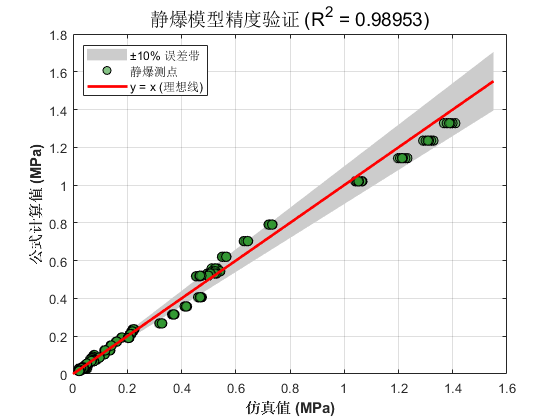

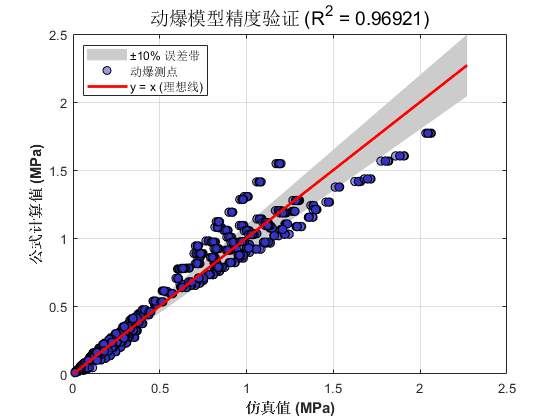

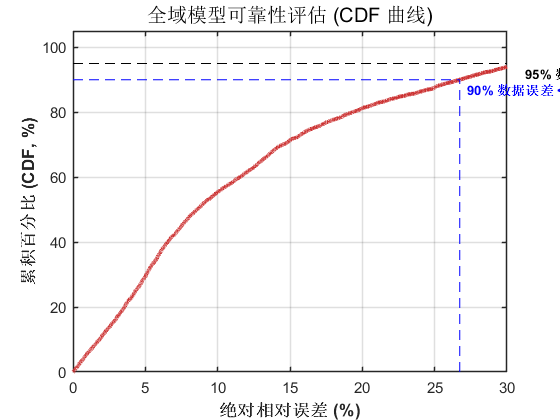

In [9]:
%% 第六步：生成拟合性能评估看板 (独立大图版) - 修复拼写错误
disp('>>> 开始生成独立维度的拟合效果评估图...');

% 1. 准备误差数据
y_static_sim = df_static.P_MPa;
y_static_calc = static_model(p_stat, [df_static.Z, df_static.Sp, df_static.theta]);
err_static = (y_static_calc - y_static_sim) ./ y_static_sim * 100;

y_dyn_sim = df_dyn.P_MPa;
y_dyn_calc = df_dyn.P_pred;
err_dyn = (y_dyn_calc - y_dyn_sim) ./ y_dyn_sim * 100;
all_errors = [err_static; err_dyn];

% =========================================================================
% 图 6.1：静爆公式等值对比图 (Parity Plot)
% =========================================================================
fig61 = figure('Position', [100, 100, 900, 800], 'Name', '静爆等值对比');
hold on; box on; grid on;
max_p = max(y_static_sim) * 1.1;
fill([0, max_p, max_p, 0], [0, max_p*1.1, max_p*0.9, 0], [0.8 0.8 0.8], 'EdgeColor', 'none', 'DisplayName', '±10% 误差带');
scatter(y_static_sim, y_static_calc, 50, 'Marker', 'o', 'MarkerFaceColor', [0.2 0.6 0.2], ...
    'MarkerEdgeColor', 'k', 'MarkerFaceAlpha', 0.6, 'DisplayName', '静爆测点');
plot([0, max_p], [0, max_p], 'r-', 'LineWidth', 2, 'DisplayName', 'y = x (理想线)');
xlabel('仿真值 (MPa)', 'FontWeight', 'bold'); ylabel('公式计算值 (MPa)', 'FontWeight', 'bold');
% 【修复1】：已将 num2 size 修正为正确的 num2str
title(['静爆模型精度验证 (R^2 = ', num2str(R2_stat), ')'], 'FontSize', 14);
legend('Location', 'northwest');
saveas(fig61, '评估A_静爆等值对比.png');

% =========================================================================
% 图 6.2：动爆公式等值对比图 (Parity Plot)
% =========================================================================
fig62 = figure('Position', [150, 150, 900, 800], 'Name', '动爆等值对比');
hold on; box on; grid on;
max_p_dyn = max(y_dyn_sim) * 1.1;
fill([0, max_p_dyn, max_p_dyn, 0], [0, max_p_dyn*1.1, max_p_dyn*0.9, 0], [0.8 0.8 0.8], 'EdgeColor', 'none', 'DisplayName', '±10% 误差带');
scatter(y_dyn_sim, y_dyn_calc, 40, 'Marker', 'o', 'MarkerFaceColor', [0.2 0.2 0.8], ...
    'MarkerEdgeColor', 'k', 'MarkerFaceAlpha', 0.5, 'DisplayName', '动爆测点');
plot([0, max_p_dyn], [0, max_p_dyn], 'r-', 'LineWidth', 2, 'DisplayName', 'y = x (理想线)');
xlabel('仿真值 (MPa)', 'FontWeight', 'bold'); ylabel('公式计算值 (MPa)', 'FontWeight', 'bold');
title(['动爆模型精度验证 (R^2 = ', num2str(R2_dyn), ')'], 'FontSize', 14);
legend('Location', 'northwest');
saveas(fig62, '评估B_动爆等值对比.png');

% =========================================================================
% 图 6.3：全样本误差累积概率分布图 (CDF)
% =========================================================================
fig63 = figure('Position', [200, 200, 1000, 700], 'Name', '误差累积分布');
hold on; box on; grid on;
set(gca, 'FontSize', 11, 'LineWidth', 1.2);
abs_err_sorted = sort(abs(all_errors));
cdf_val = (1:length(abs_err_sorted)) / length(abs_err_sorted) * 100;

% 【修复2】：修正了 RGB 颜色矩阵中的拼写错误
plot(abs_err_sorted, cdf_val, 'LineWidth', 3, 'Color', [0.8 0.2 0.2]);

% 找到并标注 90% 和 95% 置信水平
p_levels = [90, 95];
colors_lvl = ['b', 'k'];
for i = 1:length(p_levels)
    idx = find(cdf_val >= p_levels(i), 1);
    if ~isempty(idx)
        val_x = abs_err_sorted(idx);
        line([0, val_x], [p_levels(i), p_levels(i)], 'Color', colors_lvl(i), 'LineStyle', '--');
        line([val_x, val_x], [0, p_levels(i)], 'Color', colors_lvl(i), 'LineStyle', '--');
        text(val_x + 0.5, p_levels(i)-3, sprintf('%.0f%% 数据误差 < %.2f%%', p_levels(i), val_x), ...
            'FontWeight', 'bold', 'Color', colors_lvl(i));
    end
end

xlabel('绝对相对误差 (%)', 'FontSize', 13, 'FontWeight', 'bold');
ylabel('累积百分比 (CDF, %)', 'FontSize', 13, 'FontWeight', 'bold');
title('全域模型可靠性评估 (CDF 曲线)', 'FontSize', 15);
xlim([0, min(30, max(abs_err_sorted))]); ylim([0, 105]);
saveas(fig63, '评估C_误差累积分布.png');

disp('🌟 修复成功！评估图表已全部分开生成并保存为独立高清图片。');

平均绝对误差和平均相对误差值 

In [10]:
%% 补充步骤：计算并输出模型的 MAE 和 MAPE 误差指标
disp('>>> 开始计算模型的平均绝对误差与平均相对误差...');

% ==================== 1. 静爆模型误差计算 ====================
% 提取静爆仿真值与计算值
y_static_sim = df_static.P_MPa;
y_static_calc = static_model(p_stat, [df_static.Z, df_static.Sp, df_static.theta]);

% 计算绝对误差与相对百分比误差数组
abs_err_static = abs(y_static_calc - y_static_sim);
rel_err_static = (abs_err_static ./ y_static_sim) * 100;

% 计算平均值
MAE_static = mean(abs_err_static);
MAPE_static = mean(rel_err_static);

% ==================== 2. 动爆模型误差计算 ====================
% 提取动爆仿真值与计算值
y_dyn_sim = df_dyn.P_MPa;
y_dyn_calc = df_dyn.P_pred; % 直接调用第二步已算好的预测列

% 计算绝对误差与相对百分比误差数组
abs_err_dyn = abs(y_dyn_calc - y_dyn_sim);
rel_err_dyn = (abs_err_dyn ./ y_dyn_sim) * 100;

% 计算平均值
MAE_dyn = mean(abs_err_dyn);
MAPE_dyn = mean(rel_err_dyn);

% ==================== 3. 打印精美评估报表 ====================
fprintf('\n================ 威力场模型误差量化评估 =================\n');
fprintf('【静爆基础公式】 (评估样本数: %d)\n', length(y_static_sim));
fprintf('  ▶ 平均绝对误差 (MAE)  : %.5f MPa\n', MAE_static);
fprintf('  ▶ 平均相对误差 (MAPE) : %.2f %%\n', MAPE_static);
fprintf('---------------------------------------------------------\n');
fprintf('【动爆高阶公式】 (评估样本数: %d)\n', length(y_dyn_sim));
fprintf('  ▶ 平均绝对误差 (MAE)  : %.5f MPa\n', MAE_dyn);
fprintf('  ▶ 平均相对误差 (MAPE) : %.2f %%\n', MAPE_dyn);
fprintf('=========================================================\n');

% 给出工程评价建议
if MAPE_dyn < 10
    disp('💡 结论：动爆公式平均相对误差低于 10%，满足高精度武器毁伤评估要求！');
elseif MAPE_dyn < 20
    disp('💡 结论：动爆公式平均相对误差在 10%~20% 之间，满足常规工程估算要求。');
else
    disp('⚠️ 结论：平均相对误差偏大，部分极值工况可能存在欠拟合，需查阅误差表格排查。');
end

>>> 开始计算模型的平均绝对误差与平均相对误差...

================ 威力场模型误差量化评估 =================
【静爆基础公式】 (评估样本数: 784)
  ▶ 平均绝对误差 (MAE)  : 0.01784 MPa
  ▶ 平均相对误差 (MAPE) : 10.78 %
---------------------------------------------------------
【动爆高阶公式】 (评估样本数: 3920)
  ▶ 平均绝对误差 (MAE)  : 0.02753 MPa
  ▶ 平均相对误差 (MAPE) : 11.86 %
💡 结论：动爆公式平均相对误差在 10%~20% 之间，满足常规工程估算要求。



静爆公式与原始值对比

In [12]:
disp('>>> Start calculating static errors and generating sorted table...');

if ~exist('df_static', 'var') || ~exist('p_stat', 'var') || ~exist('static_model', 'var')
    error('Error: Variables not found. Run step 1 first!');
end

X_stat_curr = [df_static.Z, df_static.Sp, df_static.theta];
y_stat_sim = df_static.P_MPa;

P_stat_calc = static_model(p_stat, X_stat_curr);

Abs_Error = abs(P_stat_calc - y_stat_sim);
Rel_Error_Pct = (Abs_Error ./ y_stat_sim) * 100;

% Create table with pure English headers to avoid encoding errors
Error_Table = table(df_static.H, df_static.M, df_static.Z, df_static.theta, ...
                    y_stat_sim, P_stat_calc, Abs_Error, Rel_Error_Pct, ...
                    'VariableNames', {'H_km', 'Mass_M_kg', 'Z_value', 'Theta_deg', ...
                                      'Sim_P_MPa', 'Calc_P_MPa', ...
                                      'Abs_Err_MPa', 'Rel_Err_Pct'});

% Sort by H -> M -> Z -> Theta
Error_Table_Sorted = sortrows(Error_Table, {'H_km', 'Mass_M_kg', 'Z_value', 'Theta_deg'});

% Round values
Error_Table_Sorted.Sim_P_MPa = round(Error_Table_Sorted.Sim_P_MPa, 4);
Error_Table_Sorted.Calc_P_MPa = round(Error_Table_Sorted.Calc_P_MPa, 4);
Error_Table_Sorted.Abs_Err_MPa = round(Error_Table_Sorted.Abs_Err_MPa, 4);
Error_Table_Sorted.Rel_Err_Pct = round(Error_Table_Sorted.Rel_Err_Pct, 4);

% Export to Excel
filename = 'Static_Error_Table_with_Mass.xlsx';
writetable(Error_Table_Sorted, filename);

disp('✅ Table generated successfully!');
disp(['👉 Check your folder for: ', filename]);

>>> Start calculating static errors and generating sorted table...
✅ Table generated successfully!
👉 Check your folder for: Static_Error_Table_with_Mass.xlsx



kd对比